#

# Covering Factor Validation of MCMC-Derived Accretion Parameters in Blazars Using SS and ADAF Models

This program computes emission-line covering factors (CFs) for a sample of blazars using either a Shakura–Sunyaev (SS) accretion disk model or an ADAF model, depending on the source classification. The ionizing luminosity associated with each observed emission line is derived from the model spectrum and compared with the observed line luminosity to estimate the line-by-line CF. The resulting CFs are used as an independent consistency check of the black hole mass (M) and accretion rate (ṁ) obtained from two-parameter MCMC fits with Gaussian priors. Since physically plausible BLR covering factors are typically expected to lie in the range of approximately 5–20%, significant deviations may indicate unrealistic combinations of M and ṁ despite acceptable MCMC convergence.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import root
from scipy.special import kv

# INPUT FILES
line_file = "Tab_completa_revisione.csv"
transition_file = "dati.asc"
mcmc_file = "risultati_MCMC.csv"

## Physical constants

In [2]:
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

#SS
eta = 0.083
Nr = 2000
Nnu = 400
nu_min = 1e13
nu_max_SS = 1e17

#ADAF
ALPHA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10
beta_default = 0.5

## Blazar selection

In [3]:
# These three sources are treated as Shakura-Sunyaev objects.
SS_BLAZARS = {"J0059", "J0508", "J0133"}

# These two sources are excluded from ADAF.
# J0133 is intentionally NOT excluded because it must be computed
# both as SS and as ADAF.
EXCLUDE_FROM_ADAF = {"J0059", "J0508"}

## General utility functions

In [4]:
def find_column(df, possible_names, required=True):
    """
    Find the first matching column name in a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        Input table.
    possible_names : list of str
        Candidate column names.
    required : bool
        If True, raise an error when no column is found.

    Returns
    -------
    str or None
        Matching column name.
    """
    for name in possible_names:
        if name in df.columns:
            return name

    if required:
        raise ValueError(f"Could not find any of these columns: {possible_names}")

    return None


def read_transitions(transition_file):
    """
    Read the ionization transition file.

    The input file is expected to contain:
    line name, ionization energy, ionization frequency.
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        transition_file,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def extract_observed_lines(row, norm_columns):
    """
    Extract observed emission-line luminosities from one blazar row.

    The input line columns are assumed to end with '_norm'.
    The stored values are multiplied by 1e42 to obtain L_line.
    """
    results = []

    for col in norm_columns:
        value = row[col]

        if pd.isna(value) or value <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = value * 1e42

        results.append({
            "line_name": line_name,
            "L_line": L_line
        })

    return pd.DataFrame(results)


def compute_lion_for_transitions(nu, Lnu, df_transitions, nu_max=None):
    """
    Compute the ionizing luminosity above each ionization threshold.

    For each line:
        L_ion = integral of Lnu dnu from nu_ion to nu_max.
    """
    results = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_transitions.iterrows():

        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        results.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(results)

## SS model function

In [5]:
def build_SS_disk_spectrum(
    MBH_solar,
    mdot,
    eta=eta,
    Nr=Nr,
    Nnu=Nnu,
    nu_min=nu_min,
    nu_max=nu_max_SS
):
    """
    Build the multi-temperature blackbody spectrum
    of a Shakura-Sunyaev accretion disk.

    Parameters
    ----------
    MBH_solar : float
        Black hole mass in solar masses.
    mdot : float
        Accretion rate in Eddington units.

    Returns
    -------
    nu : numpy.ndarray
        Frequency grid.
    Lnu : numpy.ndarray
        Spectral luminosity.
    """

    MBH = MBH_solar * Msun

    # Eddington luminosity and disk luminosity
    Ledd = 1.3e38 * MBH_solar
    Ldisk = mdot * Ledd

    # Mass accretion rate
    Mdot = Ldisk / (eta * c**2)

    # Schwarzschild radius and disk radii
    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs

    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    # Inner-boundary correction
    correction = 1.0 - np.sqrt(Rin / R)
    correction = np.clip(correction, 0.0, None)

    # Disk temperature profile
    T = (
        (3 * G * MBH * Mdot)
        / (8 * np.pi * sigma * R**3)
        * correction
    )**0.25

    # Frequency grid
    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))

    # Planck function for each disk annulus
    for j in range(Nr):

        if T[j] <= 0:
            continue

        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)

        Bnu[:, j] = (
            2 * h * nu**3 / c**2
        ) / (np.exp(x) - 1.0)

    # Integrate over radius
    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)

    # Disk luminosity per unit frequency
    Lnu = 4 * np.pi**2 * I_nu

    return nu, Lnu


def analyze_blazar_SS(row, df_transitions, norm_columns):
    """
    Compute line covering factors for one blazar
    using the Shakura-Sunyaev disk model.
    """

    blazar_name = row["label"]

    nu, Lnu = build_SS_disk_spectrum(
        MBH_solar=row["m_median_Msun"],
        mdot=row["mdot_median"]
    )

    df_lion = compute_lion_for_transitions(
        nu=nu,
        Lnu=Lnu,
        df_transitions=df_transitions,
        nu_max=nu_max_SS
    )

    df_lines = extract_observed_lines(
        row=row,
        norm_columns=norm_columns
    )

    if df_lines.empty:
        return pd.DataFrame()

    df_cf = df_lines.merge(
        df_lion,
        on="line_name",
        how="left"
    )

    # Covering factor for each emission line
    df_cf["cf_line"] = df_cf["L_line"] / df_cf["L_ion"]

    # Invalid ionizing luminosities give undefined covering factors
    df_cf.loc[
        (df_cf["L_ion"].isna()) | (df_cf["L_ion"] <= 0),
        "cf_line"
    ] = np.nan

    df_cf["blazar name"] = blazar_name
    df_cf["regime"] = "SS"

    return df_cf[[
        "blazar name",
        "line_name",
        "L_ion",
        "L_line",
        "cf_line",
        "regime"
    ]]

## ADAF model function

In [6]:
def bessk(n, x):
    """
    Modified Bessel function of the second kind.
    """
    return kv(n, x)


def g(theta):
    """
    Relativistic correction function used in the ADAF equations.
    """
    return (
        (1.0 / bessk(2, 1.0 / theta))
        * (2.0 + 2.0 * theta + 1.0 / theta)
        * np.exp(-1.0 / theta)
    )


def temperature_equations(y, mdot, m, beta):
    """
    System of nonlinear ADAF equations.

    Unknowns are encoded as:
        theta = y[0]^2
        xm    = 1e3 * y[1]^2
        f     = y[2]^2

    Parameters
    ----------
    y : array-like
        Root-finding variables.
    mdot : float
        Accretion rate.
    m : float
        Black hole mass in solar masses.
    beta : float
        Ratio between gas pressure and total pressure.

    Returns
    -------
    list
        Residuals of the three ADAF equations.
    """

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    theta = y[0]**2

    s1 = (
        1.42e9
        * ALPHA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm

    # Heating terms
    q1 = (
        1.2e4
        * g(theta)
        * ALPHA**(-2)
        * C1**(-2)
        * C3
        * beta
        * m
        * mdot**2
        / RMIN
    )

    q2 = (
        DELTA
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
    )

    q = q1 + q2

    # Synchrotron peak frequency
    nu_p = (
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * (theta / TNORM)**2
        * RMIN**(-5 / 4)
    )

    # Synchrotron power
    p_sync = (
        53.0
        * (xm / 1000.0)**3
        * (theta / (1e9 * TNORM))**7
        * m**0.5
        * mdot**1.5
    )

    # Comptonization
    A = 1 + 4 * theta + 16 * theta**2
    tau = 23.87 * mdot
    alpha_c = -np.log(tau) / np.log(A)

    bracket = (
        (6.2e7 * (theta / (1e9 * TNORM)))
        / (nu_p * 1e-12)
    )**(1 - alpha_c) - 1

    p_comp = (p_sync / 0.71) / (1 - alpha_c) * bracket

    # Bremsstrahlung correction
    if theta < 1:
        f_brems = (
            4
            * np.sqrt(2 * theta / np.pi**3)
            * (1 + 1.781 * theta**1.34)
        )
    else:
        f_brems = (
            9
            * theta
            / (2 * np.pi)
            * (np.log(1.123 * theta + 0.48) + 1.5)
        )

    p_brems = (
        4.78
        * ALPHA**(-2)
        * C1**(-2)
        * np.log(RMAX / RMIN)
        * f_brems
        * m
        * mdot**2
    )

    # Energy equation
    eq1 = q - p_sync - p_comp - p_brems

    # Advection equation
    eq2 = (
        (1 - ff)
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
        - q
    )

    # Equation for xm
    vv = xm**(1 / 3)

    eq3 = (
        vv
        + 1.852 * np.log(vv)
        - 10.36
        - 0.26 * np.log(m * mdot)
        + 0.26 * np.log(theta**3 * bessk(2, 1 / theta))
    )

    return [eq1, eq3, eq2]

## Unifying models

In [7]:
def build_ADAF_spectrum_from_solution(te, f, xm, m, mdot, beta):
    """
    Build the ADAF spectrum once the nonlinear system has been solved.

    The spectrum includes three components:
        1. synchrotron emission
        2. Comptonized synchrotron emission
        3. bremsstrahlung emission

    Parameters
    ----------
    te : float
        Electron temperature.
    f : float
        Advection parameter.
    xm : float
        Synchrotron self-absorption parameter.
    m : float
        Black hole mass in solar masses.
    mdot : float
        Accretion rate.
    beta : float
        Ratio between gas pressure and total pressure.

    Returns
    -------
    log_nu : numpy.ndarray
        Logarithmic frequency grid.
    log_nuLnu : numpy.ndarray
        Logarithmic nu Lnu luminosity.
    """

    nu_min_adaf = 1e10
    nu_max_adaf = 1e21
    n_points = 100

    log_nu = np.linspace(
        np.log10(nu_min_adaf),
        np.log10(nu_max_adaf),
        n_points
    )

    nu = 10**log_nu
    theta = TNORM * te

    s1 = (
        1.42e9
        * ALPHA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    A = 1 + 4 * theta + 16 * theta**2
    tau = 23.87 * mdot
    alpha_c = -np.log(tau) / np.log(A)

    log_nu_peak = np.log10(
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * te**2
        * RMIN**(-5 / 4)
    )

    log_nu_compton_max = np.log10(te) + 10.796

    log_Lsync_integrated = (
        3 * np.log10(s1 * s2)
        + np.log10(s3)
        - (7 / 4) * np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7 * np.log10(te)
    )

    log_Lsync = np.zeros(n_points)
    log_Lcomp = np.zeros(n_points)
    log_Lbrems = np.zeros(n_points)

    for i in range(n_points):

        # Synchrotron component below the peak frequency
        if log_nu[i] < log_nu_peak:
            log_Lsync[i] = (
                np.log10(s3)
                + (8 / 5) * np.log10(s1 * s2)
                + np.log10(m**(6 / 5) * mdot**(4 / 5))
                + (21 / 5) * np.log10(te)
                + (2 / 5) * log_nu[i]
            )
        else:
            log_Lsync[i] = -np.inf

        # Comptonized component above the synchrotron peak
        if log_nu[i] > log_nu_peak:
            base = (
                log_Lsync_integrated
                + (alpha_c - 1) * log_nu_peak
                - alpha_c * log_nu[i]
            )

            cutoff = -(10**(log_nu[i] - log_nu_compton_max)) / np.log(10)

            log_Lcomp[i] = base + cutoff
        else:
            log_Lcomp[i] = -np.inf

        # Bremsstrahlung component
        if theta < 1:
            f_brems = (
                4
                * np.sqrt(2 * theta / np.pi**3)
                * (1 + 1.781 * theta**1.34)
            )
        else:
            f_brems = (
                9
                * theta
                / (2 * np.pi)
                * (np.log(1.123 * theta + 0.48) + 1.5)
            )

        base_brems = (
            24.36
            - 2 * np.log10(ALPHA * C1)
            + np.log10(np.log(RMAX / RMIN) * f_brems)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_brems = -(4.8e-11 * nu[i] / te) / np.log(10)

        log_Lbrems[i] = base_brems + cutoff_brems

    sync_component = np.where(np.isfinite(log_Lsync), 10**log_Lsync, 0.0)
    comp_component = np.where(np.isfinite(log_Lcomp), 10**log_Lcomp, 0.0)
    brems_component = np.where(np.isfinite(log_Lbrems), 10**log_Lbrems, 0.0)

    total_flux = sync_component + comp_component + brems_component

    log_nuLnu = log_nu + np.log10(total_flux)

    return log_nu, log_nuLnu


def solve_ADAF_spectrum(m, mdot, beta):
    """
    Solve the ADAF nonlinear system and return the ADAF spectrum.
    """

    initial_guess = [0.5, 1.0, 0.99]

    solution = root(
        temperature_equations,
        initial_guess,
        args=(mdot, m, beta),
        tol=1e-10
    )

    if not solution.success:
        raise RuntimeError(
            f"ADAF solution did not converge for "
            f"m={m}, mdot={mdot}, beta={beta}"
        )

    y = solution.x

    theta = y[0]**2
    te = theta / TNORM
    xm = 1e3 * y[1]**2
    f = y[2]**2

    return build_ADAF_spectrum_from_solution(
        te=te,
        f=f,
        xm=xm,
        m=m,
        mdot=mdot,
        beta=beta
    )


def build_ADAF_spectrum(m, mdot, beta=beta_default):
    """
    Build the ADAF spectral luminosity Lnu.

    Returns
    -------
    nu : numpy.ndarray
        Frequency grid.
    Lnu : numpy.ndarray
        Spectral luminosity.
    """

    log_nu, log_nuLnu = solve_ADAF_spectrum(
        m=m,
        mdot=mdot,
        beta=beta
    )

    nu = 10**log_nu
    nuLnu = 10**log_nuLnu

    Lnu = nuLnu / nu

    return nu, Lnu

## ADAF covering factor calculation

In [8]:
def analyze_blazar_ADAF(row, df_transitions, norm_columns):
    """
    Compute line covering factors for one blazar
    using the ADAF model.
    """

    blazar_name = row["label"]

    try:
        nu, Lnu = build_ADAF_spectrum(
            m=row["m_median_Msun"],
            mdot=row["mdot_median"],
            beta=beta_default
        )

    except RuntimeError as error:
        print(f"Warning: skipping {blazar_name} in ADAF. Reason: {error}")
        return pd.DataFrame()

    df_lion = compute_lion_for_transitions(
        nu=nu,
        Lnu=Lnu,
        df_transitions=df_transitions,
        nu_max=np.max(nu)
    )

    df_lines = extract_observed_lines(
        row=row,
        norm_columns=norm_columns
    )

    if df_lines.empty:
        return pd.DataFrame()

    df_cf = df_lines.merge(
        df_lion,
        on="line_name",
        how="left"
    )

    # Covering factor for each line
    df_cf["cf_line"] = df_cf["L_line"] / df_cf["L_ion"]

    # Remove invalid values
    df_cf.loc[
        (df_cf["L_ion"].isna()) | (df_cf["L_ion"] <= 0),
        "cf_line"
    ] = np.nan

    df_cf["blazar name"] = blazar_name
    df_cf["regime"] = "ADAF"

    return df_cf[[
        "blazar name",
        "line_name",
        "L_ion",
        "L_line",
        "cf_line",
        "regime"
    ]]

## Main function, final table, and output

In [9]:
# MAIN PROGRAM

def main():
    """
    Main workflow.

    Steps:
        1. Read the input tables.
        2. Standardize blazar names.
        3. Merge line measurements with MCMC parameters.
        4. Compute SS covering factors for J0059, J0508, J0133.
        5. Compute ADAF covering factors for all the other sources,
           plus J0133.
        6. Build one final table.
    """

    # ------------------------------------------------------
    # Read input files
    # ------------------------------------------------------
    df_lines = pd.read_csv(line_file)
    df_transitions = read_transitions(transition_file)
    df_mcmc = pd.read_csv(mcmc_file)

    # ------------------------------------------------------
    # Find and standardize the blazar-name column
    # ------------------------------------------------------
    line_name_column = find_column(
        df_lines,
        ["label", "file_name", "name", "nome", "blazar"]
    )

    df_lines = df_lines.rename(
        columns={line_name_column: "original_label"}
    ).copy()

    df_mcmc = df_mcmc.rename(
        columns={"Blazar": "label"}
    ).copy()

    # Remove extra spaces
    df_lines["original_label"] = (
        df_lines["original_label"]
        .astype(str)
        .str.strip()
    )

    df_mcmc["label"] = (
        df_mcmc["label"]
        .astype(str)
        .str.strip()
    )

    # Extract names such as J0059, J0133, J0508, etc.
    df_lines["label"] = (
        df_lines["original_label"]
        .str.extract(r"(J\d+)", expand=False)
    )

    df_mcmc["label"] = (
        df_mcmc["label"]
        .str.extract(r"(J\d+)", expand=False)
    )

    # Columns containing normalized line luminosities
    norm_columns = [
        col for col in df_lines.columns
        if col.endswith("_norm")
    ]

    # ------------------------------------------------------
    # Merge line table with MCMC results
    # ------------------------------------------------------
    df_all = df_lines.merge(
        df_mcmc[["label", "m_median_Msun", "mdot_median"]],
        on="label",
        how="inner"
    )

    if len(df_all) == 0:
        raise ValueError(
            "The merge did not find any blazars in common."
        )

    all_results = []

    # ------------------------------------------------------
    # SS calculation
    # ------------------------------------------------------
    df_ss = df_all[
        df_all["label"].isin(SS_BLAZARS)
    ].copy()

    for _, row in df_ss.iterrows():

        df_cf = analyze_blazar_SS(
            row=row,
            df_transitions=df_transitions,
            norm_columns=norm_columns
        )

        if not df_cf.empty:
            all_results.append(df_cf)

    # ------------------------------------------------------
    # ADAF calculation
    # ------------------------------------------------------
    # This includes all sources except J0059 and J0508.
    # Therefore J0133 is computed again as ADAF.
    df_adaf = df_all[
        ~df_all["label"].isin(EXCLUDE_FROM_ADAF)
    ].copy()

    for _, row in df_adaf.iterrows():

        df_cf = analyze_blazar_ADAF(
            row=row,
            df_transitions=df_transitions,
            norm_columns=norm_columns
        )

        if not df_cf.empty:
            all_results.append(df_cf)

    if len(all_results) == 0:
        raise ValueError(
            "No covering factors were computed."
        )

    # ------------------------------------------------------
    # Build final long-format table
    # ------------------------------------------------------
    final_table = pd.concat(
        all_results,
        ignore_index=True
    )

    # Mean covering factor for each blazar and regime
    final_table["cf mean"] = final_table.groupby(
        ["blazar name", "regime"]
    )["cf_line"].transform(
        lambda x: x.mean(skipna=True)
    )

    # Rename columns for final output
    final_table = final_table.rename(columns={
        "line_name": "line",
        "L_ion": "Lion",
        "L_line": "Lline",
        "cf_line": "cf line"
    })

    # ------------------------------------------------------
    # Sort the final table
    # ------------------------------------------------------
    regime_order = pd.CategoricalDtype(
        categories=["SS", "ADAF"],
        ordered=True
    )

    final_table["regime"] = final_table["regime"].astype(
        regime_order
    )

    line_order = pd.CategoricalDtype(
        categories=["CIII", "CIV", "MgII", "Ha", "Hb", "Hg", "Hd"],
        ordered=True
    )

    final_table["line"] = final_table["line"].astype(
        line_order
    )

    final_table = final_table.sort_values(
        by=["regime", "blazar name", "line"],
        na_position="last"
    ).reset_index(drop=True)

    final_table = final_table[[
        "blazar name",
        "line",
        "Lion",
        "Lline",
        "cf line",
        "cf mean",
        "regime"
    ]]

    # ------------------------------------------------------
    # Save and display the final table
    # ------------------------------------------------------
    final_table.to_csv(
        "final_covering_factors_SS_ADAF.csv",
        index=False
    )

    try:
        display(final_table)
    except NameError:
        print(final_table.to_string(index=False))
        print("\nFile saved as: final_covering_factors_SS_ADAF.csv")

    return final_table


if __name__ == "__main__":
    final_table = main()

,blazar name,line,Lion,Lline,cf line,cf mean,regime
0,J0059,MgII,4.169479e+43,5.311291e+43,1.273850,0.494901,SS
1,J0059,Hg,2.975618e+44,4.302412e+43,0.144589,0.494901,SS
2,J0059,Hd,2.906065e+44,1.925694e+43,0.066265,0.494901,SS
3,J0133,MgII,1.801532e+43,7.153948e+43,3.971035,1.991784,SS
4,J0133,Hd,1.459433e+45,1.829014e+43,0.012532,1.991784,SS
5,J0508,CIII,8.808755e+44,7.035330e+43,0.079867,0.301649,SS
6,J0508,CIV,7.974461e+44,4.174072e+44,0.523430,0.301649,SS
7,J0021,Hb,1.540420e+44,6.569277e+42,0.042646,0.021164,ADAF
8,J0021,Hg,1.540420e+44,1.867612e+42,0.012124,0.021164,ADAF
9,J0021,Hd,1.540420e+44,1.343418e+42,0.008721,0.021164,ADAF


## Final wide-format table

In [10]:
# Re-read MCMC file to recover mass and mdot
df_mcmc_params = pd.read_csv(mcmc_file)

df_mcmc_params = df_mcmc_params.rename(columns={
    "Blazar": "blazar name",
    "m_median_Msun": "mass",
    "mdot_median": "mdot"
})

df_mcmc_params["blazar name"] = (
    df_mcmc_params["blazar name"]
    .astype(str)
    .str.extract(r"(J\d+)", expand=False)
)

blazar_parameters = df_mcmc_params[
    ["blazar name", "mass", "mdot"]
].drop_duplicates()

# Create one column for each line
wide_table = final_table.pivot_table(
    index=["blazar name", "regime"],
    columns="line",
    values="cf line",
    aggfunc="first"
).reset_index()

# Add mass and mdot
wide_table = wide_table.merge(
    blazar_parameters,
    on="blazar name",
    how="left"
)

# Ensure all seven transition columns exist
transition_columns = [
    "CIII",
    "CIV",
    "MgII",
    "Ha",
    "Hb",
    "Hg",
    "Hd"
]

for line in transition_columns:
    if line not in wide_table.columns:
        wide_table[line] = np.nan

# Compute mean covering factor
wide_table["cf mean"] = wide_table[
    transition_columns
].mean(axis=1, skipna=True)

# Replace missing line values with "-"
wide_table[transition_columns] = wide_table[
    transition_columns
].where(
    wide_table[transition_columns].notna(),
    "-"
)

# Reorder columns
wide_table = wide_table[[
    "blazar name",
    "mass",
    "mdot",
    "CIII",
    "CIV",
    "MgII",
    "Ha",
    "Hb",
    "Hg",
    "Hd",
    "cf mean",
    "regime"
]]

# Sort table
regime_order = pd.CategoricalDtype(
    categories=["SS", "ADAF"],
    ordered=True
)

wide_table["regime"] = wide_table["regime"].astype(regime_order)

wide_table = wide_table.sort_values(
    by=["regime", "blazar name"]
).reset_index(drop=True)

# Display full table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(wide_table)

/tmp/ipykernel_10773/3278072323.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide_table = final_table.pivot_table(


,blazar name,mass,mdot,CIII,CIV,MgII,Ha,Hb,Hg,Hd,cf mean,regime
0,J0059,2.185000e+08,0.013410,-,-,1.27385,-,-,0.144589,0.066265,0.494901,SS
1,J0133,2.036000e+09,0.010220,-,-,3.971035,-,-,-,0.012532,1.991784,SS
2,J0508,6.208000e+05,12.600000,0.079867,0.52343,-,-,-,-,-,0.301649,SS
3,J0021,5.700000e+09,0.007394,-,-,-,-,0.042646,0.012124,0.008721,0.021164,ADAF
4,J0050,2.291000e+08,0.004436,-,-,-,0.195889,0.0403,0.033166,0.006055,0.068852,ADAF
5,J0133,2.036000e+09,0.010220,-,-,0.557016,-,-,-,0.139207,0.348112,ADAF
6,J0922,3.643000e+10,0.009795,-,-,0.101261,-,0.010682,0.005442,0.014115,0.032875,ADAF
7,J1123,4.540000e+09,0.006853,-,-,-,0.0213,0.041802,0.016781,0.00568,0.021391,ADAF
8,J1329,2.984000e+10,0.009633,-,-,0.035402,-,-,0.007724,0.026385,0.023170,ADAF
9,J152422,4.751000e+10,0.001137,0.016482,-,0.036401,-,-,-,0.041611,0.031498,ADAF


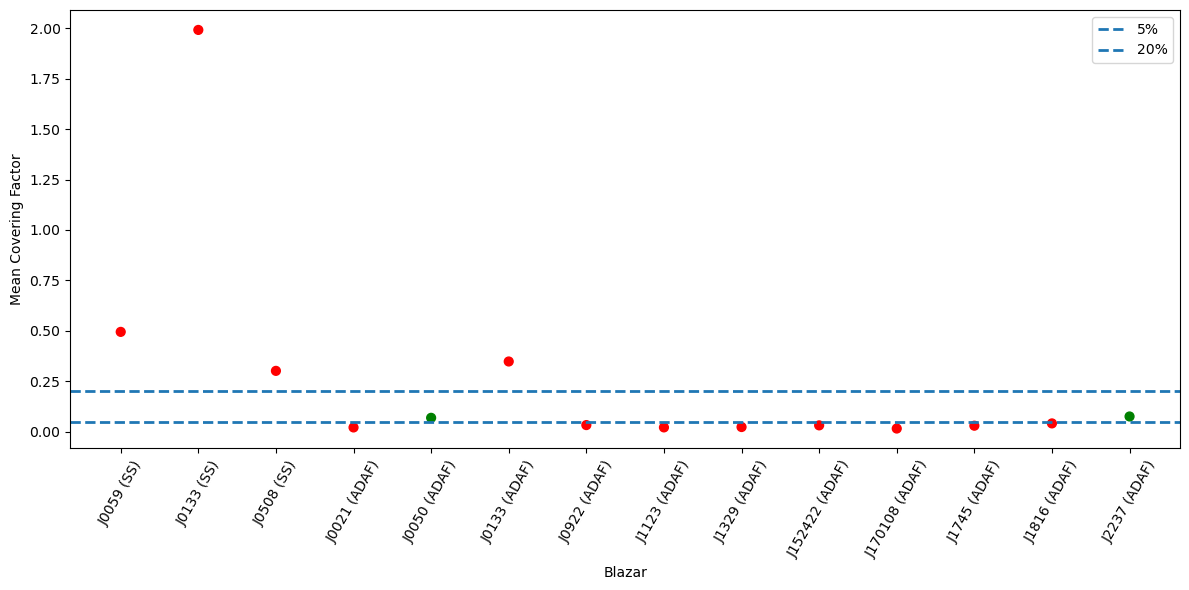

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# CF validity test

cf_min = 0.05
cf_max = 0.20

wide_table["in_range"] = (
    (wide_table["cf mean"] >= cf_min) &
    (wide_table["cf mean"] <= cf_max)
)

colors = np.where(
    wide_table["in_range"],
    "green",
    "red"
)

#Plot

plt.figure(figsize=(12,6))
plt.scatter(
    range(len(wide_table)),
    wide_table["cf mean"],
    c=colors,
    s=40
)

plt.axhline(
    cf_min,
    linestyle="--",
    linewidth=2,
    label="5%"
)

plt.axhline(
    cf_max,
    linestyle="--",
    linewidth=2,
    label="20%"
)

plt.xticks(
    range(len(wide_table)),
    wide_table["blazar name"] + " (" + wide_table["regime"].astype(str) + ")",
    rotation=60
)

plt.ylabel("Mean Covering Factor")
plt.xlabel("Blazar")
plt.legend()
plt.tight_layout()
plt.show()